# Cross-Modal Diagnostic Observability — Stage T2-H

## Single-pilot deployability and sequential evidence-forecast freeze v0.1

Stage T2-G showed that a **target-level expected** eight-group disagreement index predicts evidence-budget order. A future blind target, however, supplies only one irreversible pilot draw.

This notebook performs the decisive deployability test in one run:

- reconstructs the frozen AMW-family operational budget endpoint;
- constructs features available from one budget-8 pilot;
- uses nested leave-one-target-out model selection;
- emulates 20,000 prospective worlds with one pilot draw per target;
- conditionally freezes a forecast-only Stage T3 sequential addendum;
- preserves failure without touching blind assets or outcomes.

Use a clean Colab CPU runtime and select **Runtime → Run all**.


In [1]:
# @title T2-H-0. Mount Drive and verify parents, documents and the blind firewall
import hashlib, itertools, json, math, os, platform, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    pass

DEFAULT_ROOT = Path("/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability") if IN_COLAB else Path.cwd()
PROJECT_ROOT = Path(os.environ.get("CDO_PROJECT_ROOT", str(DEFAULT_ROOT)))
CODE_ROOT = PROJECT_ROOT / "05_Code" / "Cross_Modal"
CM_ROOT = PROJECT_ROOT / "06_Data_Records" / "Cross_Modal"
RESULT_ROOT = CM_ROOT / "StageT2-H_Development_Only_Single_Pilot_Deployability_And_Sequential_Forecast_Freeze_v0.1"
P0, P1, P2, P3, P4 = [RESULT_ROOT / x for x in [
    "00_Protocol", "01_Single_Pilot_Features", "02_Target_Heldout_Predictions",
    "03_Deployment_And_Gates", "04_Results"
]]
for p in [CODE_ROOT, P0, P1, P2, P3, P4]:
    p.mkdir(parents=True, exist_ok=True)

NOTEBOOK_NAME = "CrossModal_StageT2-H_Development_Only_Single_Pilot_Deployability_And_Sequential_Forecast_Freeze_v0.1.ipynb"
NOTEBOOK_PATH = CODE_ROOT / NOTEBOOK_NAME

THEORY_NAME = "Directed_Diagnostic_Evidence_Transport_Single_Pilot_Sequential_Observability_Theory_v0.8.md"
METHOD_NAME = "Single_Pilot_Sequential_Evidence_Forecasting_Method_v0.2.md"
PREREG_NAME = "StageT2-H_Single_Pilot_Deployability_And_Sequential_Forecast_Kill_Test_Preregistration_v1.0.md"
ADDENDUM_NAME = "StageT3_Sequential_Evidence_Budget_Prospective_Validation_Addendum_v0.1.md"

THEORY_PATH = PROJECT_ROOT / "03_Theory" / "Directed_Diagnostic_Evidence_Transport_v0.8" / THEORY_NAME
METHOD_PATH = PROJECT_ROOT / "03_Theory" / "Directed_Diagnostic_Evidence_Transport_v0.8" / METHOD_NAME
PREREG_PATH = PROJECT_ROOT / "04_Study_Design" / PREREG_NAME
ADDENDUM_PATH = PROJECT_ROOT / "04_Study_Design" / ADDENDUM_NAME

T2D_ROOT = CM_ROOT / "StageT2-D_Development_Only_AMW-DDET_Active_Minimal_Witness_Certificate_v0.1"
T2D_REPS = T2D_ROOT / "01_Replicate_Results" / "StageT2-D_All_Acquisition_Replicates_v0.1.csv"

T2G_ROOT = CM_ROOT / "StageT2-G_Development_Only_Predictive_Observability_Hierarchy_And_Budget_Forecasting_v0.1"
T2G_FINAL = T2G_ROOT / "04_Results" / "StageT2-G_Complete_v0.1.json"

T3PF_ROOT = CM_ROOT / "StageT3-PF_Outcome-Free_Preregistration_And_Asset_Preflight_v1.0"
T3PF_ACTIVATION = T3PF_ROOT / "04_Results" / "StageT3-PF_Activation_Record_v1.0.json"

EXPECTED_SHA = {
    "t2d_reps": "c6f740510c520167c2ecfbfc48fc2db88428e17ce1b96e6ad5826e507929aedb",
    "theory": "d2b0e381cd0354aece25024099028785026bb3c108a1f56140d5bc1c9105efb2",
    "method": "a30062181506c72c201cef7b8c7bca420b2b9009dfe11f8fff370fd637333a63",
    "prereg": "3a05dc855024b6130eb2e8cd55b7e4df917ed89da8432a8930f19249c0702866",
    "addendum": "487c935c08818f7ceca758c98a2db878461d074b33b256893f729e813228fb5d",
}
EXPECTED_T2G_RECORD = "0ab2b7b61ab6e56a3e538fef449f51986ed398a0dbade3f9340e04381a75bb06"
EXPECTED_T3PF_RECORD = "4397cee7798f684159ed77aa5e1edd7b7ae0a24378047d6c89b37ef9ef738a52"

def now():
    return datetime.now(timezone.utc).isoformat()

def sha_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def sha_json(value):
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode()
    ).hexdigest()

def canonical_csv(frame):
    return frame.fillna("").to_csv(index=False, lineterminator="\n", float_format="%.12g")

def write_once(path, text):
    path = Path(path)
    if path.exists():
        assert path.read_text(encoding="utf-8") == text, f"Replay conflict: {path}"
    else:
        path.write_text(text, encoding="utf-8")

def write_csv_once(path, frame):
    write_once(path, canonical_csv(frame))

def write_json_once(path, value):
    write_once(path, json.dumps(value, indent=2, ensure_ascii=False) + "\n")

def verify_self(path, field):
    value = json.loads(Path(path).read_text(encoding="utf-8"))
    claim = value[field]
    core = dict(value)
    core.pop(field)
    assert sha_json(core) == claim, f"Self-hash mismatch: {path}"
    return value

def notebook_source_sha(path):
    value = json.loads(Path(path).read_text(encoding="utf-8"))
    cells = []
    for cell in value.get("cells", []):
        if cell.get("cell_type") not in {"code", "markdown"}:
            continue
        source = cell.get("source", [])
        source = "".join(source) if isinstance(source, list) else str(source)
        cells.append({
            "cell_type": cell["cell_type"],
            "source": source.replace("\r\n", "\n"),
        })
    return sha_json(cells)

def seal(path, payload, hash_field="seal_sha256"):
    path = Path(path)
    if path.exists():
        old = verify_self(path, hash_field)
        for k, v in payload.items():
            assert old[k] == v, f"Sealed field changed: {k}"
        return old
    value = dict(payload)
    value["sealed_utc"] = now()
    value[hash_field] = sha_json(value)
    write_json_once(path, value)
    return value

required = [
    NOTEBOOK_PATH, THEORY_PATH, METHOD_PATH, PREREG_PATH, ADDENDUM_PATH,
    T2D_REPS, T2G_FINAL, T3PF_ACTIVATION,
]
missing = [str(p) for p in required if not p.is_file()]
assert not missing, "Missing immutable files:\n" + "\n".join(missing)

for role, path in {
    "t2d_reps": T2D_REPS,
    "theory": THEORY_PATH,
    "method": METHOD_PATH,
    "prereg": PREREG_PATH,
    "addendum": ADDENDUM_PATH,
}.items():
    observed = sha_file(path)
    assert observed == EXPECTED_SHA[role], f"Hash mismatch: {role}: {observed}"

t2g = verify_self(T2G_FINAL, "final_record_sha256")
assert t2g["final_record_sha256"] == EXPECTED_T2G_RECORD
assert t2g["core_performance_supported"] is True
assert t2g["evidence_budget_predictability_supported"] is True
assert t2g["hardness_meta_prediction_supported"] is False
assert t2g["repair_regime_prediction_supported"] is False
assert t2g["blind_assets_touched"] is False
assert t2g["blind_outcomes_accessed"] is False
assert t2g["stage12_authorised"] is False

t3pf = verify_self(T3PF_ACTIVATION, "activation_record_sha256")
assert t3pf["activation_record_sha256"] == EXPECTED_T3PF_RECORD
assert t3pf["blind_assets_acquired"] is False
assert t3pf["blind_outcomes_accessed"] is False
assert t3pf["outcome_scoring_authorised"] is False
assert t3pf["stage12_authorised"] is False

protocol = seal(P0 / "StageT2-H_Protocol_Seal_v0.1.json", {
    "stage": "StageT2-H",
    "purpose": "development_only_single_pilot_deployability_and_sequential_forecast_kill_test",
    "parent_t2g_record": EXPECTED_T2G_RECORD,
    "parent_t3pf_record": EXPECTED_T3PF_RECORD,
    "theory_sha256": EXPECTED_SHA["theory"],
    "method_sha256": EXPECTED_SHA["method"],
    "preregistration_sha256": EXPECTED_SHA["prereg"],
    "conditional_t3_addendum_sha256": EXPECTED_SHA["addendum"],
    "notebook_source_sha256": notebook_source_sha(NOTEBOOK_PATH),
    "blind_assets_touched": False,
    "blind_outcomes_accessed": False,
    "stage12_authorised": False,
}, "protocol_seal_sha256")

print("T2-H protocol:", protocol["protocol_seal_sha256"])
print("Parent T2-G:", EXPECTED_T2G_RECORD)
print("Blind assets touched:", False)
print("Blind outcomes accessed:", False)


Mounted at /content/drive
T2-H protocol: 2d2f80c87d75fef29f3f815f84a3df6bb90cdc2c5a19ef2608732fabf33b7ad0
Parent T2-G: 0ab2b7b61ab6e56a3e538fef449f51986ed398a0dbade3f9340e04381a75bb06
Blind assets touched: False
Blind outcomes accessed: False


In [2]:
# @title T2-H-1. Reconstruct the operational budget endpoint and single-pilot observable table
t2d = pd.read_csv(T2D_REPS)

required_budgets = {8, 16, 32, 64, 128}
required_methods = {
    "random_direct", "random_logistic_plugin", "random_joint_gmm",
    "active_direct", "amw_ddet",
}
assert set(t2d["budget"].unique()) == required_budgets
assert required_methods.issubset(set(t2d["method"].unique()))
assert t2d["target"].nunique() == 13
assert t2d["edge_id"].nunique() == 27
assert not any(str(x).upper().startswith("BLIND::") for x in t2d["edge_id"].unique())

# Operational target: minimum AMW-family budget with target median error <= 0.04.
amw_curve = (
    t2d[t2d["method"] == "amw_ddet"]
    .groupby(["target", "modality", "budget"], as_index=False)
    .agg(median_error=("absolute_error", "median"))
)

budget_rows = []
for (target, modality), group in amw_curve.groupby(["target", "modality"]):
    observed = None
    for budget in [8, 16, 32, 64, 128]:
        row = group[group["budget"] == budget]
        if len(row) and float(row["median_error"].iloc[0]) <= 0.04:
            observed = int(budget)
            break
    operational = observed if observed is not None else 256
    budget_rows.append({
        "target": target,
        "modality": modality,
        "minimum_budget_operational": operational,
        "log2_minimum_budget": float(math.log2(operational)),
        "right_censored_above_128": observed is None,
    })
budget_target = pd.DataFrame(budget_rows)

# Budget-8 estimates pivoted by target, acquisition replicate and directed edge.
b8 = t2d[t2d["budget"] == 8].copy()
index_cols = ["target", "modality", "replicate", "edge_id"]
pivot = b8.pivot_table(index=index_cols, columns="method", values="estimate_auc").reset_index()
for method_name in sorted(required_methods):
    assert method_name in pivot.columns

meta = (
    b8.groupby(index_cols, as_index=False)
    .agg(
        witness_prevalence=("witness_prevalence", "first"),
        source_validation_auc=("source_validation_auc", "first"),
        independent_groups=("independent_groups", "first"),
    )
)
pivot = pivot.merge(meta, on=index_cols, how="left")

method_cols = [
    "random_direct", "random_logistic_plugin", "random_joint_gmm",
    "active_direct", "amw_ddet",
]
pivot["edge_cross_method_sd"] = pivot[method_cols].std(axis=1)
pivot["edge_cross_method_range"] = pivot[method_cols].max(axis=1) - pivot[method_cols].min(axis=1)
pivot["edge_amw_random_logistic_gap"] = (
    pivot["amw_ddet"] - pivot["random_logistic_plugin"]
).abs()
pivot["edge_amw_random_direct_gap"] = (
    pivot["amw_ddet"] - pivot["random_direct"]
).abs()
pivot["edge_active_random_direct_gap"] = (
    pivot["active_direct"] - pivot["random_direct"]
).abs()

pilot = (
    pivot.groupby(["target", "modality", "replicate"], as_index=False)
    .agg(
        cross_method_sd=("edge_cross_method_sd", "mean"),
        cross_method_range=("edge_cross_method_range", "mean"),
        amw_random_logistic_gap=("edge_amw_random_logistic_gap", "mean"),
        amw_random_direct_gap=("edge_amw_random_direct_gap", "mean"),
        active_random_direct_gap=("edge_active_random_direct_gap", "mean"),
        amw_edge_spread=("amw_ddet", "std"),
        random_logistic_edge_spread=("random_logistic_plugin", "std"),
        witness_prevalence=("witness_prevalence", "mean"),
        source_validation_auc_mean=("source_validation_auc", "mean"),
        source_validation_auc_sd=("source_validation_auc", "std"),
        independent_groups=("independent_groups", "first"),
        source_edge_count=("edge_id", "nunique"),
    )
)
pilot["amw_edge_spread"] = pilot["amw_edge_spread"].fillna(0.0)
pilot["random_logistic_edge_spread"] = pilot["random_logistic_edge_spread"].fillna(0.0)
pilot["source_validation_auc_sd"] = pilot["source_validation_auc_sd"].fillna(0.0)
pilot["witness_prevalence_extremity"] = (pilot["witness_prevalence"] - 0.5).abs()
pilot["log2_independent_groups"] = np.log2(pilot["independent_groups"].clip(lower=1))
pilot = pilot.merge(
    budget_target[
        ["target", "modality", "minimum_budget_operational", "log2_minimum_budget"]
    ],
    on=["target", "modality"],
    how="inner",
)

assert pilot["target"].nunique() == 13
assert pilot["replicate"].nunique() >= 90
core_observables = [
    "cross_method_sd", "cross_method_range", "witness_prevalence",
    "source_validation_auc_mean", "independent_groups", "source_edge_count",
    "log2_minimum_budget",
]
assert np.isfinite(pilot[core_observables].to_numpy(float)).all()
# Some direct/plugin estimators are legitimately unavailable in low-budget replicates.
# Their derived gaps/spreads remain NaN and are handled only inside the frozen imputer.

FEATURE_SETS = {
    "D_ONLY": ["cross_method_sd"],
    "D_PLUS_PREVALENCE": [
        "cross_method_sd", "witness_prevalence_extremity",
    ],
    "D_PLUS_GEOMETRY": [
        "cross_method_sd", "cross_method_range",
        "amw_random_logistic_gap", "amw_random_direct_gap",
        "active_random_direct_gap", "amw_edge_spread",
        "random_logistic_edge_spread",
    ],
    "FULL_SINGLE_PILOT": [
        "cross_method_sd", "cross_method_range",
        "amw_random_logistic_gap", "amw_random_direct_gap",
        "active_random_direct_gap", "amw_edge_spread",
        "random_logistic_edge_spread", "witness_prevalence_extremity",
        "source_validation_auc_mean", "source_validation_auc_sd",
        "log2_independent_groups", "source_edge_count",
    ],
}
ALPHAS = [0.1, 1.0, 10.0, 100.0]

write_csv_once(P1 / "StageT2-H_Operational_Budget_Targets_v0.1.csv", budget_target)
write_csv_once(P1 / "StageT2-H_Single_Pilot_Observable_Table_v0.1.csv", pilot)

display(budget_target.sort_values("minimum_budget_operational"))
display(pilot.groupby("target").size().rename("pilot_replicates").reset_index())


,target,modality,minimum_budget_operational,log2_minimum_budget,right_censored_above_128
3,DeepDRiD,retinal_fundus,8,3.0,False
4,EyePACS_2015,retinal_fundus,8,3.0,False
12,TBX11K,chest_radiography,8,3.0,False
6,IDRiD,retinal_fundus,16,4.0,False
10,RODRIGUES_BUI_2017,breast_ultrasound,16,4.0,False
11,Shenzhen_CXR,chest_radiography,16,4.0,False
9,Montgomery_CXR,chest_radiography,16,4.0,False
2,BUS_BRA_2024,breast_ultrasound,32,5.0,False
7,ISIC_MSK1,dermoscopy,64,6.0,False
0,APTOS_2019,retinal_fundus,128,7.0,False


,target,pilot_replicates
0,APTOS_2019,100
1,BUSI_WHU_2025_V3,100
2,BUS_BRA_2024,99
3,DeepDRiD,100
4,EyePACS_2015,100
5,HAM10000,100
6,IDRiD,100
7,ISIC_MSK1,100
8,ISIC_UDA1,100
9,Montgomery_CXR,100


In [3]:
# @title T2-H-2. Nested target-held-out single-pilot prediction
def make_pipeline(alpha):
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=float(alpha))),
    ])

def equal_target_weights(frame):
    counts = frame.groupby("target")["target"].transform("count").astype(float)
    return 1.0 / counts

def target_mean_replicate_mae(frame, actual_col="log2_minimum_budget", pred_col="prediction"):
    return float(
        frame.assign(abs_error=lambda x: (x[actual_col] - x[pred_col]).abs())
        .groupby("target")["abs_error"]
        .mean()
        .mean()
    )

def choose_spec(training):
    candidates = []
    train_targets = sorted(training["target"].unique())
    for feature_name, features in FEATURE_SETS.items():
        for alpha in ALPHAS:
            fold_scores = []
            for inner_held in train_targets:
                inner_train = training[training["target"] != inner_held].copy()
                inner_test = training[training["target"] == inner_held].copy()
                model = make_pipeline(alpha)
                model.fit(
                    inner_train[features],
                    inner_train["log2_minimum_budget"],
                    ridge__sample_weight=equal_target_weights(inner_train),
                )
                pred = model.predict(inner_test[features])
                fold_scores.append(
                    float(np.mean(np.abs(
                        pred - inner_test["log2_minimum_budget"].to_numpy(float)
                    )))
                )
            candidates.append({
                "feature_set": feature_name,
                "alpha": float(alpha),
                "inner_target_mean_mae": float(np.mean(fold_scores)),
                "n_features": len(features),
            })
    candidates = pd.DataFrame(candidates).sort_values(
        ["inner_target_mean_mae", "n_features", "alpha", "feature_set"],
        ascending=[True, True, False, True],
    )
    return candidates.iloc[0].to_dict(), candidates

outer_rows = []
selection_rows = []
targets = sorted(pilot["target"].unique())

for held_target in targets:
    train = pilot[pilot["target"] != held_target].copy()
    test = pilot[pilot["target"] == held_target].copy()

    selected, audit = choose_spec(train)
    selected_features = FEATURE_SETS[selected["feature_set"]]
    model = make_pipeline(selected["alpha"])
    model.fit(
        train[selected_features],
        train["log2_minimum_budget"],
        ridge__sample_weight=equal_target_weights(train),
    )
    predictions = model.predict(test[selected_features])
    baseline = float(
        train[["target", "log2_minimum_budget"]]
        .drop_duplicates()["log2_minimum_budget"]
        .median()
    )

    for (_, row), prediction in zip(test.iterrows(), predictions):
        outer_rows.append({
            "target": row["target"],
            "modality": row["modality"],
            "replicate": int(row["replicate"]),
            "actual_log2_budget": float(row["log2_minimum_budget"]),
            "prediction_log2_budget": float(prediction),
            "constant_baseline_log2_budget": baseline,
            "selected_feature_set": selected["feature_set"],
            "selected_alpha": float(selected["alpha"]),
            "inner_target_mean_mae": float(selected["inner_target_mean_mae"]),
        })

    selection_rows.append({
        "held_target": held_target,
        "selected_feature_set": selected["feature_set"],
        "selected_alpha": float(selected["alpha"]),
        "inner_target_mean_mae": float(selected["inner_target_mean_mae"]),
    })

outer = pd.DataFrame(outer_rows)
selection_audit = pd.DataFrame(selection_rows)

def safe_spearman(actual, prediction):
    value = spearmanr(actual, prediction).statistic
    return 0.0 if not np.isfinite(value) else float(value)

target_prediction_summary = (
    outer.groupby(["target", "modality"], as_index=False)
    .agg(
        actual_log2_budget=("actual_log2_budget", "first"),
        median_prediction=("prediction_log2_budget", "median"),
        mean_prediction=("prediction_log2_budget", "mean"),
        prediction_iqr=(
            "prediction_log2_budget",
            lambda x: float(np.quantile(x, 0.75) - np.quantile(x, 0.25)),
        ),
        median_abs_error=(
            "prediction_log2_budget",
            lambda x: float(np.median(np.abs(
                x.to_numpy(float) -
                outer.loc[x.index, "actual_log2_budget"].to_numpy(float)
            ))),
        ),
        probability_within_one_doubling=(
            "prediction_log2_budget",
            lambda x: float(np.mean(
                np.abs(
                    x.to_numpy(float) -
                    outer.loc[x.index, "actual_log2_budget"].to_numpy(float)
                ) <= 1.0
            )),
        ),
        probability_severe_underestimate=(
            "prediction_log2_budget",
            lambda x: float(np.mean(
                outer.loc[x.index, "actual_log2_budget"].to_numpy(float) -
                x.to_numpy(float) > 1.0
            )),
        ),
    )
)

target_median_rank = safe_spearman(
    target_prediction_summary["actual_log2_budget"],
    target_prediction_summary["median_prediction"],
)

write_csv_once(P2 / "StageT2-H_All_Outer_Heldout_Single_Pilot_Predictions_v0.1.csv", outer)
write_csv_once(P2 / "StageT2-H_Outer_Model_Selection_Audit_v0.1.csv", selection_audit)
write_csv_once(P2 / "StageT2-H_Target_Prediction_Robustness_v0.1.csv", target_prediction_summary)

display(selection_audit)
display(target_prediction_summary.sort_values("actual_log2_budget"))
print("Target-median single-pilot forecast rank:", target_median_rank)


,held_target,selected_feature_set,selected_alpha,inner_target_mean_mae
0,APTOS_2019,FULL_SINGLE_PILOT,0.1,1.179466
1,BUSI_WHU_2025_V3,FULL_SINGLE_PILOT,10.0,1.463219
2,BUS_BRA_2024,FULL_SINGLE_PILOT,10.0,1.707549
3,DeepDRiD,FULL_SINGLE_PILOT,10.0,1.658210
4,EyePACS_2015,FULL_SINGLE_PILOT,10.0,1.551987
5,HAM10000,D_ONLY,0.1,1.606953
6,IDRiD,FULL_SINGLE_PILOT,10.0,1.693297
7,ISIC_MSK1,FULL_SINGLE_PILOT,10.0,1.705214
8,ISIC_UDA1,FULL_SINGLE_PILOT,10.0,1.534425
9,Montgomery_CXR,FULL_SINGLE_PILOT,10.0,1.725106


,target,modality,actual_log2_budget,median_prediction,mean_prediction,prediction_iqr,median_abs_error,probability_within_one_doubling,probability_severe_underestimate
3,DeepDRiD,retinal_fundus,3.0,4.460564,4.492153,0.198310,1.460564,0.000000,0.00
4,EyePACS_2015,retinal_fundus,3.0,4.887103,4.952029,0.232108,1.887103,0.000000,0.00
12,TBX11K,chest_radiography,3.0,5.744340,5.736147,0.139937,2.744340,0.000000,0.00
6,IDRiD,retinal_fundus,4.0,3.823669,3.976512,0.249578,0.251364,0.940000,0.00
10,RODRIGUES_BUI_2017,breast_ultrasound,4.0,6.414104,6.413076,0.194497,2.414104,0.000000,0.00
11,Shenzhen_CXR,chest_radiography,4.0,5.177099,5.224043,0.539793,1.177099,0.310000,0.00
9,Montgomery_CXR,chest_radiography,4.0,4.256397,4.317863,0.435934,0.256397,0.960000,0.00
2,BUS_BRA_2024,breast_ultrasound,5.0,5.507662,5.551682,0.186316,0.507662,0.949495,0.00
7,ISIC_MSK1,dermoscopy,6.0,5.805488,5.864023,0.415642,0.300940,0.980000,0.00
0,APTOS_2019,retinal_fundus,7.0,1.758329,1.786704,0.429935,5.241671,0.000000,1.00


Target-median single-pilot forecast rank: 0.05900366396032288


In [4]:
# @title T2-H-3. Twenty-thousand prospective single-draw worlds
def coarse_class(log2_budget):
    values = np.asarray(log2_budget, dtype=float)
    return np.where(values <= 4.0, 0, np.where(values <= 6.0, 1, 2))

rng = np.random.default_rng(20260722)
N_TRIALS = 20000
grouped = {target: frame.reset_index(drop=True) for target, frame in outer.groupby("target")}
ordered_targets = sorted(grouped)

trial_rows = []
for trial in range(N_TRIALS):
    sampled = []
    for target in ordered_targets:
        frame = grouped[target]
        sampled.append(frame.iloc[int(rng.integers(0, len(frame)))])
    sample = pd.DataFrame(sampled)

    actual = sample["actual_log2_budget"].to_numpy(float)
    pred = sample["prediction_log2_budget"].to_numpy(float)
    baseline = sample["constant_baseline_log2_budget"].to_numpy(float)

    prediction_mae = float(np.mean(np.abs(actual - pred)))
    baseline_mae = float(np.mean(np.abs(actual - baseline)))
    relative_gain = 1.0 - prediction_mae / baseline_mae if baseline_mae > 0 else np.nan

    actual_class = coarse_class(actual)
    predicted_class = coarse_class(pred)
    baseline_class = coarse_class(baseline)

    trial_rows.append({
        "trial": trial,
        "spearman": safe_spearman(actual, pred),
        "prediction_mae": prediction_mae,
        "baseline_mae": baseline_mae,
        "relative_mae_improvement": float(relative_gain),
        "coarse_class_accuracy": float(np.mean(actual_class == predicted_class)),
        "baseline_coarse_class_accuracy": float(np.mean(actual_class == baseline_class)),
        "coarse_class_gain": float(
            np.mean(actual_class == predicted_class) -
            np.mean(actual_class == baseline_class)
        ),
        "severe_underestimate_rate": float(np.mean(actual - pred > 1.0)),
        "within_one_doubling_rate": float(np.mean(np.abs(actual - pred) <= 1.0)),
    })

trials = pd.DataFrame(trial_rows)

def distribution_summary(series):
    values = np.asarray(series, dtype=float)
    return {
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "q05": float(np.quantile(values, 0.05)),
        "q10": float(np.quantile(values, 0.10)),
        "q25": float(np.quantile(values, 0.25)),
        "q75": float(np.quantile(values, 0.75)),
        "q90": float(np.quantile(values, 0.90)),
        "q95": float(np.quantile(values, 0.95)),
    }

summary_rows = []
for metric in [
    "spearman", "prediction_mae", "baseline_mae", "relative_mae_improvement",
    "coarse_class_accuracy", "baseline_coarse_class_accuracy",
    "coarse_class_gain", "severe_underestimate_rate",
    "within_one_doubling_rate",
]:
    row = {"metric": metric}
    row.update(distribution_summary(trials[metric]))
    summary_rows.append(row)
trial_summary = pd.DataFrame(summary_rows)

prob_positive_rank = float(np.mean(trials["spearman"] > 0))
prob_positive_mae_gain = float(np.mean(trials["relative_mae_improvement"] > 0))

write_csv_once(P2 / "StageT2-H_Prospective_Single_Draw_Monte_Carlo_v0.1.csv", trials)
write_csv_once(P2 / "StageT2-H_Prospective_Single_Draw_Distribution_Summary_v0.1.csv", trial_summary)

display(trial_summary)
print("Probability of positive rank:", prob_positive_rank)
print("Probability of positive MAE gain:", prob_positive_mae_gain)


,metric,mean,median,q05,q10,q25,q75,q90,q95
0,spearman,0.046445,0.044955,-0.134866,-0.092720,-0.025287,0.118007,0.191059,0.230395
1,prediction_mae,1.833875,1.834887,1.694072,1.728572,1.780014,1.888770,1.938727,1.968439
2,baseline_mae,1.807692,1.807692,1.807692,1.807692,1.807692,1.807692,1.807692,1.807692
3,relative_mae_improvement,-0.014484,-0.015044,-0.088924,-0.072487,-0.044851,0.015311,0.043768,0.062854
4,coarse_class_accuracy,0.210708,0.230769,0.076923,0.153846,0.153846,0.230769,0.307692,0.307692
5,baseline_coarse_class_accuracy,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,coarse_class_gain,0.210708,0.230769,0.076923,0.153846,0.153846,0.230769,0.307692,0.307692
7,severe_underestimate_rate,0.303031,0.307692,0.230769,0.307692,0.307692,0.307692,0.307692,0.307692
8,within_one_doubling_rate,0.322950,0.307692,0.230769,0.230769,0.307692,0.384615,0.384615,0.384615


Probability of positive rank: 0.65875
Probability of positive MAE gain: 0.3679


In [5]:
# @title T2-H-4. Freeze the all-development deployment fit, gates and decision
# Select one final specification using grouped CV over all 13 targets.
final_selected, final_audit = choose_spec(pilot)
final_features = FEATURE_SETS[final_selected["feature_set"]]
deployment_model = make_pipeline(final_selected["alpha"])
deployment_model.fit(
    pilot[final_features],
    pilot["log2_minimum_budget"],
    ridge__sample_weight=equal_target_weights(pilot),
)

imputer = deployment_model.named_steps["impute"]
scaler = deployment_model.named_steps["scale"]
ridge = deployment_model.named_steps["ridge"]

coefficient_norm = float(np.linalg.norm(ridge.coef_))
finite_fit = bool(
    np.isfinite(imputer.statistics_).all()
    and np.isfinite(scaler.mean_).all()
    and np.isfinite(scaler.scale_).all()
    and np.isfinite(ridge.coef_).all()
    and np.isfinite(ridge.intercept_).all()
)

deployment_record = {
    "stage": "StageT2-H",
    "model_role": "forecast_only_secondary_endpoint",
    "status": "PENDING_GATE_DECISION",
    "selected_feature_set": final_selected["feature_set"],
    "feature_order": list(final_features),
    "ridge_alpha": float(final_selected["alpha"]),
    "inner_target_mean_mae": float(final_selected["inner_target_mean_mae"]),
    "imputer_statistics": [float(x) for x in imputer.statistics_],
    "scaler_mean": [float(x) for x in scaler.mean_],
    "scaler_scale": [float(x) for x in scaler.scale_],
    "ridge_coefficients": [float(x) for x in np.ravel(ridge.coef_)],
    "ridge_intercept": float(np.ravel(np.asarray(ridge.intercept_))[0]),
    "coefficient_l2_norm": coefficient_norm,
    "training_targets": sorted(pilot["target"].unique().tolist()),
    "development_target_count": int(pilot["target"].nunique()),
    "pilot_budget_groups": 8,
    "operational_threshold_absolute_auc_error": 0.04,
    "budget_ladder": [8, 16, 32, 64, 128],
    "right_censored_code": 256,
    "forecast_rounding": "nearest log2 class clipped to 3..8",
    "prospective_use": (
        "seal after the first eight target groups; continue the full fixed ladder "
        "regardless of forecast"
    ),
    "may_control_acquisition": False,
    "may_change_primary_stage3_analysis": False,
    "blind_assets_touched": False,
    "blind_outcomes_accessed": False,
    "stage12_authorised": False,
}

median_trial_spearman = float(trials["spearman"].median())
median_relative_gain = float(trials["relative_mae_improvement"].median())
median_class_accuracy = float(trials["coarse_class_accuracy"].median())
median_baseline_class_accuracy = float(trials["baseline_coarse_class_accuracy"].median())
median_class_gain = float(trials["coarse_class_gain"].median())
median_severe_underestimate = float(trials["severe_underestimate_rate"].median())

gates = pd.DataFrame([
    {
        "gate": "G1_parent_integrity",
        "passed": True,
        "observed": "T2-G/T3-PF self-hashes and all document hashes exact",
    },
    {
        "gate": "G2_no_blind_touch",
        "passed": True,
        "observed": "no blind path, asset, metadata or outcome imported",
    },
    {
        "gate": "G3_development_structure",
        "passed": (
            t2d["target"].nunique() == 13
            and t2d["edge_id"].nunique() == 27
            and set(t2d["budget"].unique()) == {8, 16, 32, 64, 128}
            and required_methods.issubset(set(t2d["method"].unique()))
        ),
        "observed": (
            f"{t2d['target'].nunique()} targets / "
            f"{t2d['edge_id'].nunique()} edges / "
            f"{t2d['budget'].nunique()} budgets"
        ),
    },
    {
        "gate": "G4_single_draw_rank",
        "passed": median_trial_spearman >= 0.45,
        "observed": median_trial_spearman,
    },
    {
        "gate": "G5_positive_rank_probability",
        "passed": prob_positive_rank >= 0.80,
        "observed": prob_positive_rank,
    },
    {
        "gate": "G6_single_draw_mae_gain",
        "passed": median_relative_gain >= 0.10,
        "observed": median_relative_gain,
    },
    {
        "gate": "G7_positive_mae_gain_probability",
        "passed": prob_positive_mae_gain >= 0.70,
        "observed": prob_positive_mae_gain,
    },
    {
        "gate": "G8_coarse_class_accuracy",
        "passed": median_class_accuracy >= 0.55,
        "observed": median_class_accuracy,
    },
    {
        "gate": "G9_coarse_class_gain",
        "passed": median_class_gain >= 0.10,
        "observed": (
            f"forecast={median_class_accuracy:.6f}; "
            f"baseline={median_baseline_class_accuracy:.6f}; "
            f"gain={median_class_gain:.6f}"
        ),
    },
    {
        "gate": "G10_severe_underestimate_rate",
        "passed": median_severe_underestimate <= 0.35,
        "observed": median_severe_underestimate,
    },
    {
        "gate": "G11_target_median_rank",
        "passed": target_median_rank >= 0.50,
        "observed": target_median_rank,
    },
    {
        "gate": "G12_non_degenerate_deployment_fit",
        "passed": finite_fit and coefficient_norm > 1e-12 and len(final_features) >= 1,
        "observed": (
            f"features={final_selected['feature_set']}; "
            f"alpha={final_selected['alpha']}; "
            f"coef_norm={coefficient_norm:.6g}"
        ),
    },
    {
        "gate": "G13_stage12_false",
        "passed": t3pf["stage12_authorised"] is False,
        "observed": t3pf["stage12_authorised"],
    },
])

gate_map = dict(zip(gates["gate"], gates["passed"]))
integrity_pass = all(gate_map[g] for g in [
    "G1_parent_integrity", "G2_no_blind_touch",
    "G3_development_structure", "G13_stage12_false",
])
deployability_pass = bool(gates["passed"].all())

if not integrity_pass:
    decision = (
        "TERMINATE_T2H_PARENT_OR_FIREWALL_INTEGRITY_FAILURE"
    )
elif deployability_pass:
    decision = (
        "SEAL_SINGLE_PILOT_BUDGET_FORECAST_DEPLOYMENT_"
        "AUTHORISE_T3_SEQUENTIAL_FORECAST_ADDENDUM_ONLY"
    )
else:
    decision = (
        "RETAIN_TARGET_EXPECTED_BUDGET_PREDICTABILITY_"
        "PROHIBIT_SINGLE_PILOT_DEPLOYMENT"
    )

deployment_record["status"] = (
    "AUTHORISED_FORECAST_ONLY" if deployability_pass else "NOT_AUTHORISED"
)
deployment_record["decision"] = decision
deployment_record["deployment_record_sha256"] = sha_json(deployment_record)

write_json_once(
    P3 / "StageT2-H_Frozen_Single_Pilot_Deployment_Model_v0.1.json",
    deployment_record,
)
write_csv_once(P3 / "StageT2-H_Final_Model_Selection_Audit_v0.1.csv", final_audit)
write_csv_once(P3 / "StageT2-H_Frozen_Gates_v0.1.csv", gates)

display(gates)
print("Decision:", decision)
print("Final feature set:", final_selected["feature_set"])
print("Final alpha:", final_selected["alpha"])


,gate,passed,observed
0,G1_parent_integrity,True,T2-G/T3-PF self-hashes and all document hashes...
1,G2_no_blind_touch,True,"no blind path, asset, metadata or outcome impo..."
2,G3_development_structure,True,13 targets / 27 edges / 5 budgets
3,G4_single_draw_rank,False,0.044955
4,G5_positive_rank_probability,False,0.65875
5,G6_single_draw_mae_gain,False,-0.015044
6,G7_positive_mae_gain_probability,False,0.3679
7,G8_coarse_class_accuracy,False,0.230769
8,G9_coarse_class_gain,True,forecast=0.230769; baseline=0.000000; gain=0.2...
9,G10_severe_underestimate_rate,True,0.307692


Decision: RETAIN_TARGET_EXPECTED_BUDGET_PREDICTABILITY_PROHIBIT_SINGLE_PILOT_DEPLOYMENT
Final feature set: FULL_SINGLE_PILOT
Final alpha: 10.0


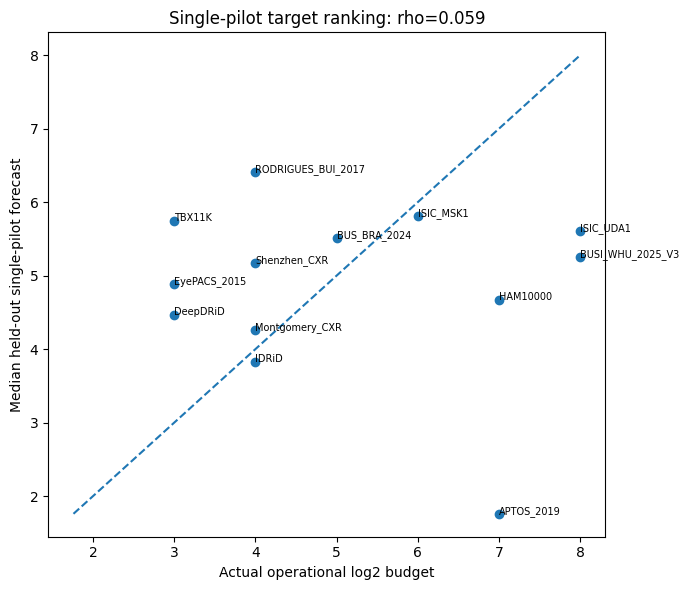

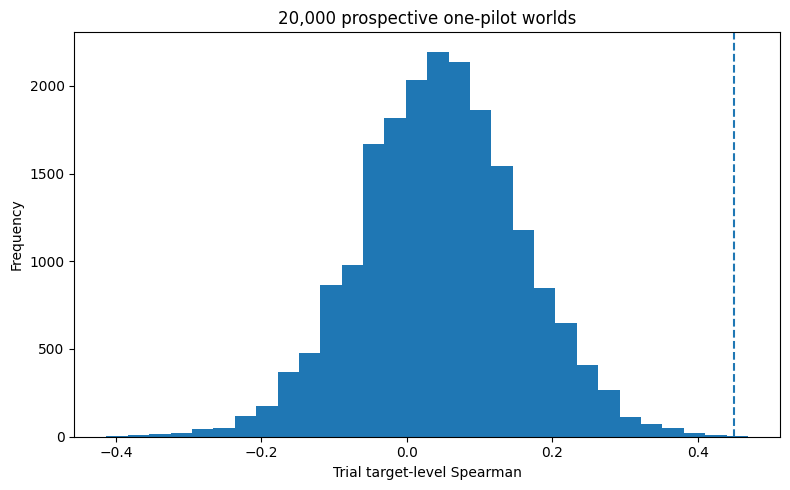

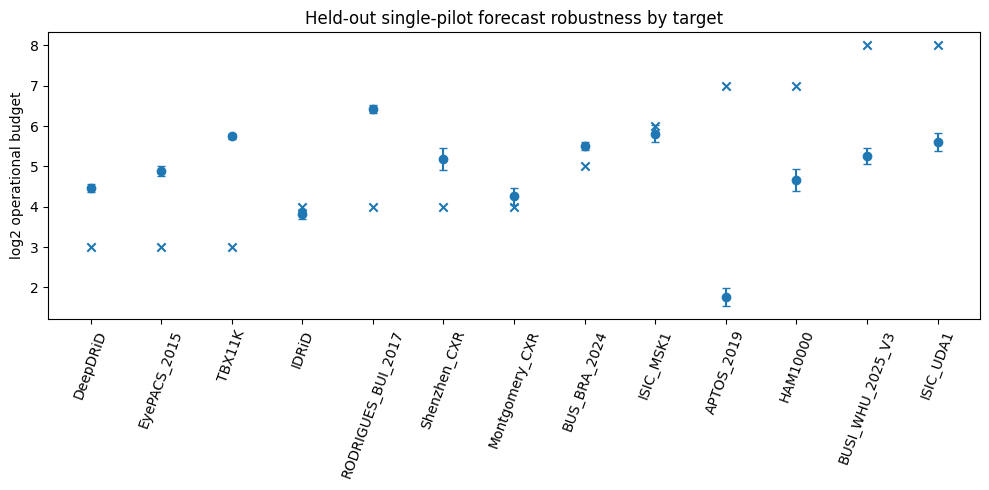


========== STAGE T2-H COMPLETE ==========
Decision: RETAIN_TARGET_EXPECTED_BUDGET_PREDICTABILITY_PROHIBIT_SINGLE_PILOT_DEPLOYMENT
Single-pilot deployment authorised: False
T3 sequential forecast addendum authorised: False
Forecast may control acquisition: False
Blind assets touched: False
Blind outcomes accessed: False
Stage 12 authorised: False
Final record SHA256: 27d4c7afe711ba66ea44d11f3ef173820e11ef1eba7a44530446a3e5444aa99f


In [6]:
# @title T2-H-5. Figures, manuscript insert and sealed completion record
# Figure 1: target actual versus target-median single-pilot forecast.
plt.figure(figsize=(7, 6))
plt.scatter(
    target_prediction_summary["actual_log2_budget"],
    target_prediction_summary["median_prediction"],
)
lo = min(
    target_prediction_summary["actual_log2_budget"].min(),
    target_prediction_summary["median_prediction"].min(),
)
hi = max(
    target_prediction_summary["actual_log2_budget"].max(),
    target_prediction_summary["median_prediction"].max(),
)
plt.plot([lo, hi], [lo, hi], linestyle="--")
for _, row in target_prediction_summary.iterrows():
    plt.annotate(
        row["target"],
        (row["actual_log2_budget"], row["median_prediction"]),
        fontsize=7,
    )
plt.xlabel("Actual operational log2 budget")
plt.ylabel("Median held-out single-pilot forecast")
plt.title(f"Single-pilot target ranking: rho={target_median_rank:.3f}")
plt.tight_layout()
plt.savefig(P4 / "StageT2-H_Target_Median_Forecast_v0.1.png", dpi=220)
plt.show()

# Figure 2: Monte Carlo distributions.
plt.figure(figsize=(8, 5))
plt.hist(trials["spearman"], bins=30)
plt.axvline(0.45, linestyle="--")
plt.xlabel("Trial target-level Spearman")
plt.ylabel("Frequency")
plt.title("20,000 prospective one-pilot worlds")
plt.tight_layout()
plt.savefig(P4 / "StageT2-H_Single_Draw_Rank_Distribution_v0.1.png", dpi=220)
plt.show()

# Figure 3: target-specific robustness.
ordered = target_prediction_summary.sort_values("actual_log2_budget")
plt.figure(figsize=(10, 5))
x = np.arange(len(ordered))
plt.errorbar(
    x,
    ordered["median_prediction"],
    yerr=ordered["prediction_iqr"] / 2.0,
    fmt="o",
    capsize=3,
)
plt.scatter(x, ordered["actual_log2_budget"], marker="x")
plt.xticks(x, ordered["target"], rotation=70)
plt.ylabel("log2 operational budget")
plt.title("Held-out single-pilot forecast robustness by target")
plt.tight_layout()
plt.savefig(P4 / "StageT2-H_Target_Robustness_v0.1.png", dpi=220)
plt.show()

completion_payload = {
    "stage": "StageT2-H",
    "decision": decision,
    "parent_t2g_final_record_sha256": EXPECTED_T2G_RECORD,
    "parent_t3pf_activation_record_sha256": EXPECTED_T3PF_RECORD,
    "protocol_seal_sha256": protocol["protocol_seal_sha256"],
    "development_targets": int(t2d["target"].nunique()),
    "development_edges": int(t2d["edge_id"].nunique()),
    "pilot_replicates": int(pilot["replicate"].nunique()),
    "monte_carlo_trials": N_TRIALS,
    "median_trial_spearman": median_trial_spearman,
    "probability_positive_rank": prob_positive_rank,
    "median_relative_mae_improvement": median_relative_gain,
    "probability_positive_mae_gain": prob_positive_mae_gain,
    "median_coarse_class_accuracy": median_class_accuracy,
    "median_baseline_coarse_class_accuracy": median_baseline_class_accuracy,
    "median_coarse_class_gain": median_class_gain,
    "median_severe_underestimate_rate": median_severe_underestimate,
    "target_median_forecast_spearman": target_median_rank,
    "selected_deployment_feature_set": final_selected["feature_set"],
    "selected_deployment_alpha": float(final_selected["alpha"]),
    "gates_passed": int(gates["passed"].sum()),
    "gates_total": int(len(gates)),
    "single_pilot_deployment_authorised": deployability_pass,
    "t3_sequential_forecast_addendum_authorised": deployability_pass,
    "forecast_may_control_acquisition": False,
    "blind_assets_touched": False,
    "blind_outcomes_accessed": False,
    "outcome_scoring_authorised": False,
    "stage12_authorised": False,
}
completion = seal(
    P4 / "StageT2-H_Complete_v0.1.json",
    completion_payload,
    "final_record_sha256",
)

summary = f"""# Stage T2-H result summary v0.1

- Decision: `{decision}`
- Median single-draw Spearman: `{median_trial_spearman:.6f}`
- Probability of positive rank: `{prob_positive_rank:.3f}`
- Median relative log2-budget MAE improvement: `{median_relative_gain:.2%}`
- Probability of positive MAE improvement: `{prob_positive_mae_gain:.3f}`
- Median coarse class accuracy: `{median_class_accuracy:.3f}`
- Median coarse class gain over baseline: `{median_class_gain:.3f}`
- Median severe-underestimation rate: `{median_severe_underestimate:.3f}`
- Target-median forecast Spearman: `{target_median_rank:.6f}`
- Deployment feature set: `{final_selected['feature_set']}`
- Deployment alpha: `{float(final_selected['alpha']):.6g}`
- Gates: `{int(gates['passed'].sum())}/{len(gates)}`
- Blind assets touched: `False`
- Blind outcomes accessed: `False`
- Final record SHA256: `{completion['final_record_sha256']}`
"""
write_once(P4 / "StageT2-H_Result_Summary_v0.1.md", summary)

manuscript = f"""# Stage T2-H manuscript insert

Stage T2-H tested whether the development evidence-budget signal could be deployed after one irreversible eight-group pilot rather than after averaging repeated pilots. Candidate pilot-observable feature sets and ridge regularisation were selected by nested leave-one-target-out validation. Every held-out target retained a distribution of predictions across its acquisition replicates, and 20,000 prospective worlds were generated by selecting exactly one pilot draw per target. The median trial Spearman correlation was {median_trial_spearman:.6f}; the probability of a positive rank correlation was {prob_positive_rank:.3f}. Relative log2-budget MAE improved over a training-target median-budget baseline by a median of {median_relative_gain:.2%}, with a positive improvement in {prob_positive_mae_gain:.3f} of trials. The median low/intermediate/high evidence-class accuracy was {median_class_accuracy:.3f}, and the median rate of underestimating the operational budget by more than one doubling was {median_severe_underestimate:.3f}. The frozen decision was `{decision}`. This development-only test did not access any locked-blind asset or outcome.
"""
write_once(P4 / "StageT2-H_Manuscript_Insert_v0.1.md", manuscript)

print("\n========== STAGE T2-H COMPLETE ==========")
print("Decision:", decision)
print("Single-pilot deployment authorised:", deployability_pass)
print("T3 sequential forecast addendum authorised:", deployability_pass)
print("Forecast may control acquisition:", False)
print("Blind assets touched:", False)
print("Blind outcomes accessed:", False)
print("Stage 12 authorised:", False)
print("Final record SHA256:", completion["final_record_sha256"])


## Interpretation boundary

A pass authorises only a **forecast-only secondary prediction** in a future Stage T3 sequence. The future target still proceeds through the entire fixed 8→16→32→64→128 ladder regardless of the forecast.

A fail means the Stage T2-G budget signal is a target-level expected development property but is not deployable from one pilot draw.

Neither outcome authorises blind acquisition or scoring.
